## 1. 초기 세팅

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
%pip install -q \
    "numpy==2.2.6" \
    "numba==0.61.2" \
    "anomalib==2.6.0" \
    jedi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 60.0 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 66.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 106.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 

In [5]:
%pip install --force-reinstall --no-cache-dir "numpy==2.1.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 296.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [6]:
import numpy as np
import numba
import torch
import anomalib

print("NumPy    :", np.__version__)
print("Numba    :", numba.__version__)
print("PyTorch  :", torch.__version__)
print("CUDA     :", torch.cuda.is_available())
print("Anomalib :", anomalib.__version__)

NumPy    : 2.1.3
Numba    : 0.61.2
PyTorch  : 2.11.0+cu128
CUDA     : True
Anomalib : 2.6.0


In [7]:
from anomalib.data import MVTecAD
from anomalib.models import Patchcore

print("Anomalib import success!")

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/dinomaly/components/layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


Anomalib import success!


## 2. MVTec AD bottle 데이터셋 구조 확인

In [11]:
from anomalib.data import MVTecAD

datamodule = MVTecAD(
    root="./datasets/MVTecAD",
    category="bottle",
)

In [12]:
datamodule.prepare_data()

In [13]:
!find ./datasets/MVTecAD/bottle -maxdepth 2 -type d | sort

./datasets/MVTecAD/bottle
./datasets/MVTecAD/bottle/ground_truth
./datasets/MVTecAD/bottle/ground_truth/broken_large
./datasets/MVTecAD/bottle/ground_truth/broken_small
./datasets/MVTecAD/bottle/ground_truth/contamination
./datasets/MVTecAD/bottle/test
./datasets/MVTecAD/bottle/test/broken_large
./datasets/MVTecAD/bottle/test/broken_small
./datasets/MVTecAD/bottle/test/contamination
./datasets/MVTecAD/bottle/test/good
./datasets/MVTecAD/bottle/train
./datasets/MVTecAD/bottle/train/good


In [14]:
from pathlib import Path

root = Path("./datasets/MVTecAD/bottle")

train_good = list((root / "train" / "good").glob("*.png"))
test_good = list((root / "test" / "good").glob("*.png"))
test_broken_large = list((root / "test" / "broken_large").glob("*.png"))
test_broken_small = list((root / "test" / "broken_small").glob("*.png"))
test_contamination = list((root / "test" / "contamination").glob("*.png"))

print("Train good       :", len(train_good))
print("Test good        :", len(test_good))
print("Broken large     :", len(test_broken_large))
print("Broken small     :", len(test_broken_small))
print("Contamination    :", len(test_contamination))

Train good       : 209
Test good        : 20
Broken large     : 20
Broken small     : 22
Contamination    : 21


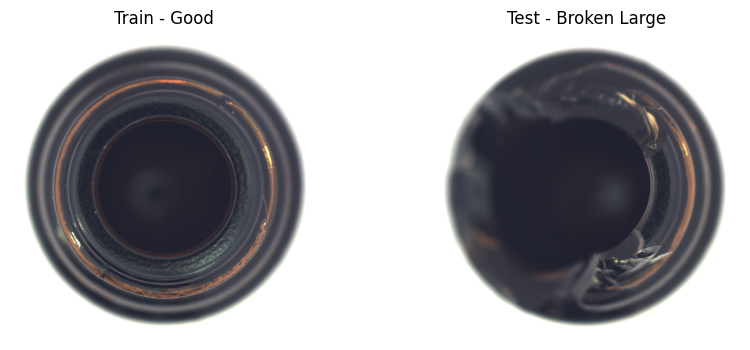

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

good_img = Image.open(train_good[0])
bad_img = Image.open(test_broken_large[0])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(good_img)
plt.title("Train - Good")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bad_img)
plt.title("Test - Broken Large")
plt.axis("off")

plt.show()